In [1]:
import os
import sys
import math
import itertools
from pathlib import Path
import pickle
# --- 科学计算 ---
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
import scipy.sparse as sp
# --- 空间计量 / 空间权重 ---
from libpysal import weights
from libpysal.weights import util, WSP
from esda import Moran_Local
# --- 深度学习 ---
import torch
# --- 可视化 ---
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.cm import get_cmap
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib import font_manager, rcParams
import seaborn as sns
import re
from collections.abc import Mapping
from analysis import bivariate_gaussian,top1_component_overlap,load_pkl_by_timestep,replace_outliers_custom

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/weights/util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")
/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/examples/remotes.py:24: UserWarning: Remote data sets not available. Check connection.
  warnings.warn("Remote data sets not available. Check connection.")


In [2]:
from numpy.polynomial.legendre import leggauss
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as ticker

In [3]:
from analysis import risk_field_properties,risk_field_stats,gmm_overlap_score

In [4]:
# 添加 Trajectron++ 所在路径
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_gen/trajectron')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_ana')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/trajectron')
#from analysis import gaussian_parameter,bivariate_gaussian,gmm_overlap_score,load_pkl_by_timestep,replace_outliers_custom

plt.rcParams.update({ 
    'font.family' : 'Liberation Serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    # 隐藏上边框和刻度
    'axes.spines.top': True,
    # 保留其他边框和小刻度
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    # 刻度朝内
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    # 右侧和上侧的刻度也朝内
    'xtick.top': False,
    'ytick.right': False,
    # 关闭网格
    'axes.grid': False,
})
#TJ_tru_94_VEHICLE

In [5]:
with open('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_pre_full_82_1950.pkl', 'rb') as f:
    pre_full = pickle.load(f)
with open('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_tru_82_1950.pkl', 'rb') as f:
    tru = pickle.load(f)
with open('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_his_82_1950.pkl', 'rb') as f:
    his = pickle.load(f)

In [6]:
def key_to_str(k):
    # Trajectron Node: 有 type.name 和 id
    if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
        return f"{k.type.name}/{k.id}"  # id 会自动转成 str
    return str(k)
pre_full = {
    key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
    for outer_k, outer_v in pre_full.items()}
tru  = {
    key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
    for outer_k, outer_v in tru.items()}
his  = {
    key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
    for outer_k, outer_v in his.items()}

In [7]:
def print_two_level_keys(pre_full):
    for outer_k, inner_dict in pre_full.items():
        print(str(outer_k))                      # 打印第一层键
        for inner_k in inner_dict.keys():
            print("   →", str(inner_k))         # 打印第二层键，缩进
#print_two_level_keys(pre_full)

In [8]:
def tra_data(time_step,agent_id):
    ts = str(time_step)
    # frame_list=list(pre_full.keys())
    # for node in tru[frame_list[time_step]].keys():
    #     print('e',int(f'{str(node.id )}'.split('/')[-1]))
    #     if node.type == 'PEDESTRIAN' and int(f'{str(node.id )}'.split('/')[-1])==car_id:  # 注意id是字符串
    tru_traj = np.asarray(tru[ts][agent_id])
    his_traj = np.asarray(his[ts][agent_id])
    pre_traj = np.asarray(pre_full[ts][agent_id])
        # break  # 找到就退出
    return tru_traj,his_traj,pre_traj[0]

In [9]:
base_path = '/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ'

In [10]:
mus_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_mus_82_VEHICLE_1950.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_sigmas_82_VEHICLE_1950.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_log_pis_82_VEHICLE_1950.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_corrs_82_VEHICLE_1950.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
id_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_id_82_VEHICLE_1950.pkl')) 
frame_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_frame_82_VEHICLE_1950.pkl'))

mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_mus_82_PEDESTRIAN_1950.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_sigmas_82_PEDESTRIAN_1950.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_log_pis_82_PEDESTRIAN_1950.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_corrs_82_PEDESTRIAN_1950.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
id_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_id_82_PEDESTRIAN_1950.pkl'))
frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_frame_82_PEDESTRIAN_1950.pkl'))

In [11]:
# 输入一个时间步长，判断他在frame_all_ped的索引，索引可能存在多个，基于这个索引在id_all_ped找到相应的行人id。在根据输入行人id（例如输入的是'PEDESTRIAN/178'，根据'178'来判断）得到目标行人的索引。这个索引是唯一一个。基于这个索引x输出相应的mus_all_ped[x]，sigmas_all_ped[x]，log_pis_all_ped[x]，corrs_all_ped[x]

In [12]:
def gaussian_parameter(time_step, agent_id):
    """
    输入:
        time_step : int
        agent_id  : 'PEDESTRIAN/178' 或 'VEHICLE/178'
    输出:
        mus[x], sigmas[x], log_pis[x], corrs[x]
    """
    # 取 ID 末尾数字
    target_id = agent_id.split('/')[-1]   # '178'
    # 判断行人 / 车辆
    if agent_id.startswith("PEDESTRIAN/"):
        frame_arr = frame_all_ped
        id_arr    = id_all_ped
        mus_arr   = mus_all_ped
        sig_arr   = sigmas_all_ped
        logpi_arr = log_pis_all_ped
        corr_arr  = corrs_all_ped
    elif agent_id.startswith("VEHICLE/"):
        frame_arr = frame_all_car
        id_arr    = id_all_car
        mus_arr   = mus_all_car
        sig_arr   = sigmas_all_car
        logpi_arr = log_pis_all_car
        corr_arr  = corrs_all_car
    else:
        raise ValueError(f"ID 必须以 'PEDESTRIAN/' 或 'VEHICLE/' 开头: {agent_id}")
    # 转 numpy（确保可 where）
    frame_arr = np.asarray(frame_arr)
    id_arr    = np.asarray(id_arr)
    # 找到所有时间步匹配
    idx_ts = np.where(frame_arr == time_step)[0]
    # 匹配对应ID（直接比较字符串）
    matches = [i for i in idx_ts if str(id_arr[i]).split('/')[-1] == target_id]
    if len(matches) == 0:
        raise ValueError(f"time_step={time_step} 下没有找到 {agent_id}")
    if len(matches) > 1:
        raise ValueError(f"time_step={time_step} 下找到多个 {agent_id}，应唯一 → {matches}")
    x = matches[0]
    return mus_arr[x], sig_arr[x], logpi_arr[x], corr_arr[x],_

In [13]:
frame_list=list(pre_full.keys())

In [14]:
ped_name_per_timestep = []
ped_number_per_timestep = []
car_name_per_timestep = []
car_number_per_timestep = []
for T in range(len(frame_list)):
    frame_key = frame_list[T]  # 外层键，如 '1', '2', '3'
    agent_ids = list(pre_full[frame_key].keys())  # ['VEHICLE/8', 'PEDESTRIAN/12', ...]
    # 分离车辆与行人
    cars = [aid for aid in agent_ids if aid.startswith("VEHICLE/")]
    peds = [aid for aid in agent_ids if aid.startswith("PEDESTRIAN/")]
    # 记录
    car_name_per_timestep.append(cars)
    car_number_per_timestep.append(len(cars))
    ped_name_per_timestep.append(peds)
    ped_number_per_timestep.append(len(peds))

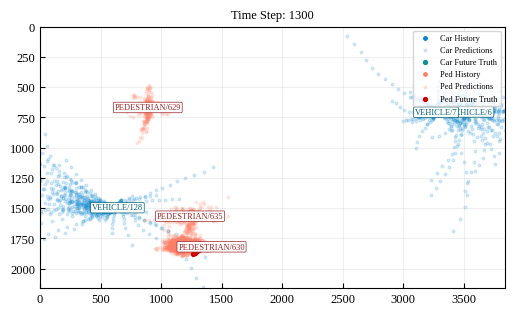

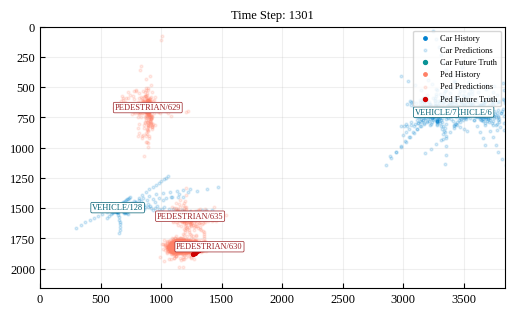

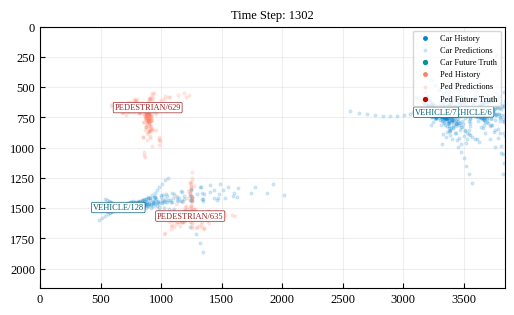

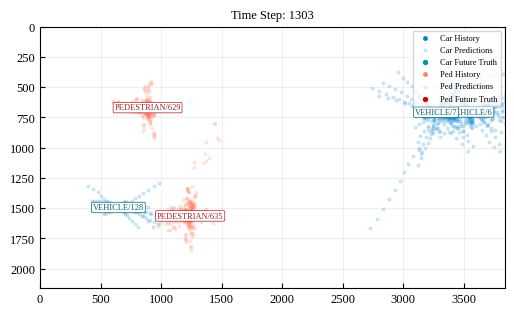

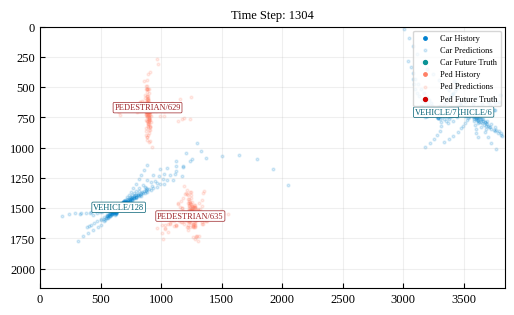

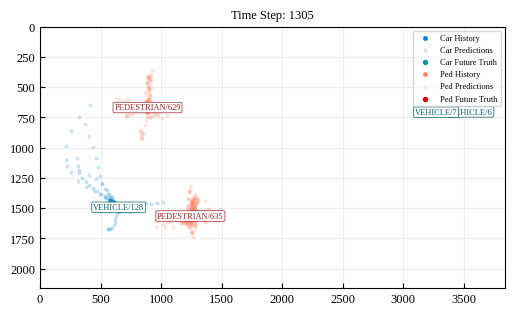

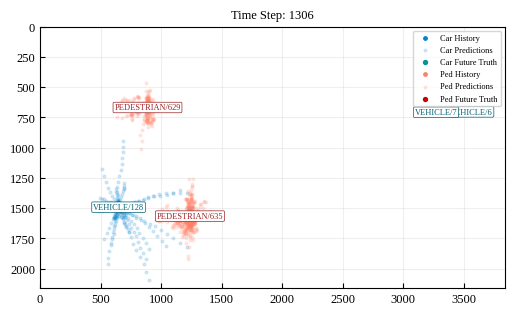

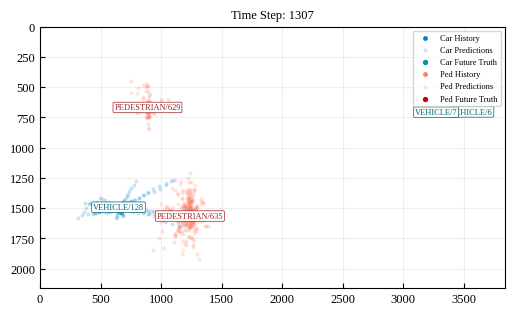

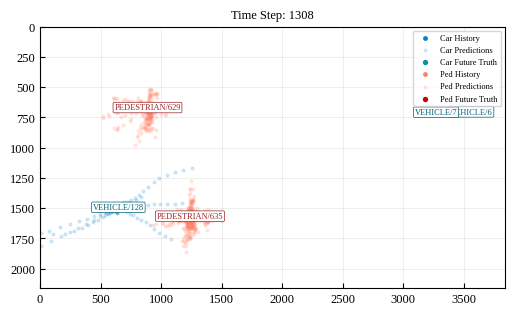

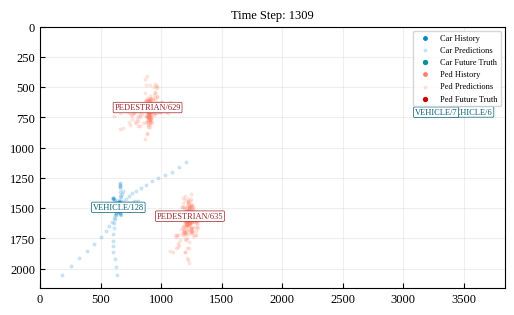

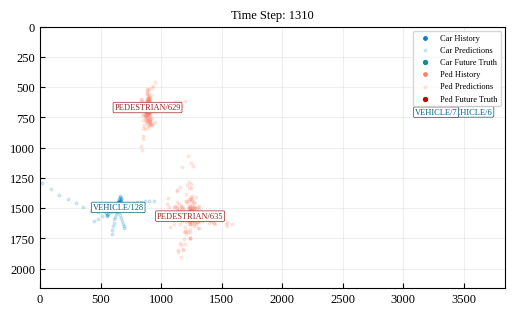

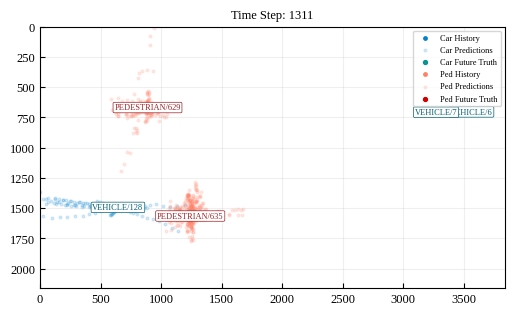

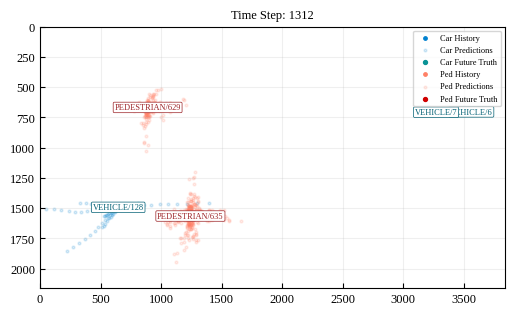

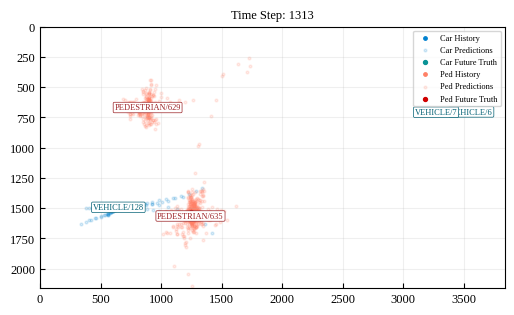

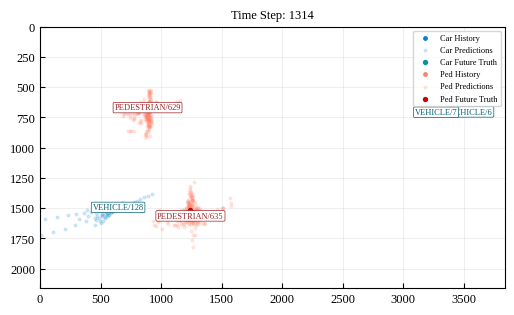

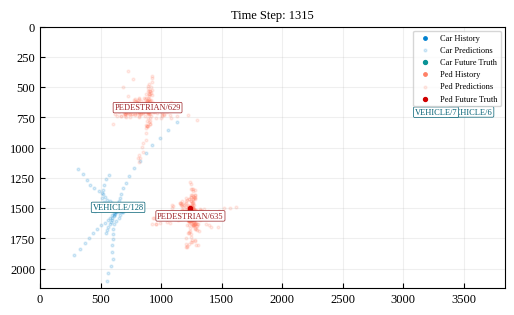

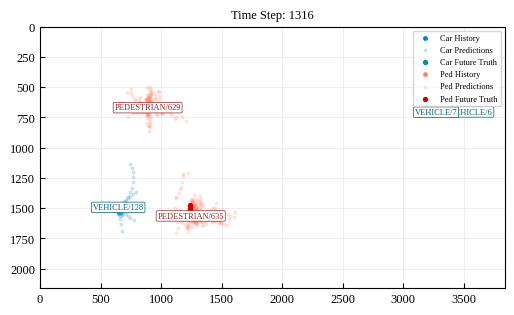

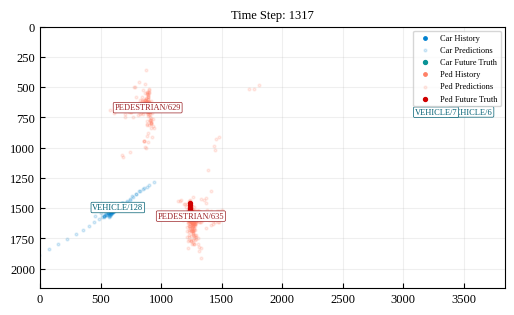

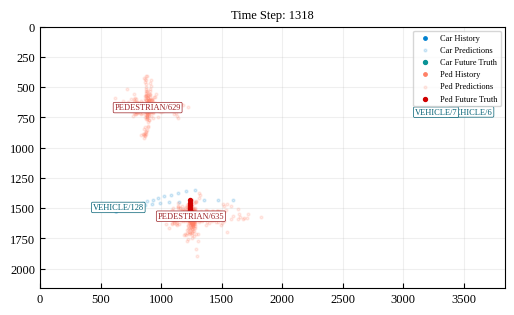

KeyboardInterrupt: 

In [15]:
for time_step in frame_list:
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 背景图（如不需要可注释掉）
    # img = plt.imread(r'/home/wangtao/下载/Trajectron_ped_car/SinD/Chongqing_NR/Chongqing_NR.png')
    # ax.imshow(img, extent=[0, 3840, 0,2160], zorder=0, alpha=0.85)
    
    # ========== ① 先画车辆 ==========
    for agent in tru[time_step].keys():
        
        if agent.startswith("VEHICLE/"):
            #print(agent)
            tru_car, his_car, pre_car = tra_data(time_step, agent)

            ax.scatter(his_car[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_car[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0081cf', s=6, label='Car History', zorder=2)
            ax.scatter(pre_car[:, :, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_car[:, :, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0081cf', alpha=0.15, s=4, label='Car Predictions', zorder=1)
            ax.scatter(tru_car[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), tru_car[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0a9396', s=8, label='Car Future Truth', zorder=3)

            if his_car.shape[0] > 0:
                ax.text(his_car[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_car[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), agent,
                        fontsize=6, color='#005f73',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#005f73', lw=0.5), zorder=4)
        else:
    # ========== ② 再画行人（颜色区分） ==========
            #print(agent)

            tru_p, his_p, pre_p = tra_data(time_step, agent)

            ax.scatter(his_p[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_p[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#ff8066', s=6, label='Ped History', zorder=2)
            ax.scatter(pre_p[:, :, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_p[:, :, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#ff8066', alpha=0.15, s=4, label='Ped Predictions', zorder=1)
            ax.scatter(tru_p[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), tru_p[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#d00000', s=8, label='Ped Future Truth', zorder=3)

            if his_p.shape[0] > 0:
                ax.text(his_p[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_p[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), agent,
                        fontsize=6, color='#9b2226',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#9b2226', lw=0.5), zorder=4)

    # ========== 坐标 & 样式 ==========
    ax.set_title(f'Time Step: {time_step}')
    ax.set_aspect('equal')
    ax.set_xlim(0, 3840)
    ax.set_ylim(2160, 0)   # 坐标原点在左上角
    ax.grid(alpha=0.2)

    # 去除重复图例（可选）
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=6, loc='upper right')

    plt.show()

In [16]:
BG_IMG_PATH = r'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png'

# ===== 像素/世界坐标映射（按你原代码保持一致）=====
W, H = 3840, 2160
X_L, X_R = 23.99, 55.51
Y_T, Y_B = 7.643, 38.69

def _tx(x):
    return np.asarray(x, float) * (W / (X_L + X_R)) + X_L * (W / (X_L + X_R))

def _ty(y):
    return np.asarray(y, float) * (H / (Y_T + Y_B)) + 7.64 * (H / (Y_T + Y_B))

def _scatter_traj(ax, his, pre, tru,
                  color_his, color_pre, color_tru,
                  marker_his='o', marker_pre='x', marker_tru='^',
                  s_his=20, s_pre=18, s_tru=28,
                  alpha_his=0.9, alpha_pre=0.2, alpha_tru=0.95,
                  label_his=None, label_pre=None, label_tru=None):
    """
    把 his/pre/tru 全部做坐标转换后画出来（支持 pre 为 (N,K,2) 或 (K,2)）。
    用不同 marker 区分历史/预测/真值，并且 legend 能正确显示。
    """
    # 1) 历史
    if hasattr(his, "size") and his.size:
        ax.scatter(
            _tx(his[:, 0]), _ty(his[:, 1]),
            c=color_his, s=s_his, alpha=alpha_his,
            marker=marker_his, zorder=3,
            label=label_his
        )

    # 2) 预测
    if hasattr(pre, "size") and pre.size:
        pre_np = np.asarray(pre)

        def _plot_pre_xy(pre_xy, label_once=True):
            ax.scatter(
                _tx(pre_xy[:, 0]), _ty(pre_xy[:, 1]),
                c=color_pre, s=s_pre, alpha=alpha_pre,
                marker=marker_pre, zorder=2,
                label=label_pre if label_once else None
            )

        if pre_np.ndim == 3 and pre_np.shape[-1] == 2:
            # 常见： (N,K,2) 或 (1,K,2) 或 (K,1,2)
            if pre_np.shape[0] == 1:
                _plot_pre_xy(pre_np[0], label_once=True)
            elif pre_np.shape[1] == 1:
                _plot_pre_xy(pre_np[:, 0, :], label_once=True)
            else:
                # 多条预测：逐条画，label 只加一次
                for i in range(pre_np.shape[0]):
                    _plot_pre_xy(pre_np[i], label_once=(i == 0))

        elif pre_np.ndim == 2 and pre_np.shape[1] == 2:
            _plot_pre_xy(pre_np, label_once=True)

    # 3) 真值未来轨迹
    if hasattr(tru, "size") and tru.size:
        ax.scatter(
            _tx(tru[:, 0]), _ty(tru[:, 1]),
            c=color_tru, s=s_tru, alpha=alpha_tru,
            marker=marker_tru, zorder=4,
            label=label_tru
        )



In [17]:
def two_agent_conflict_p(gaussian_parameter,time_step, pre_time_step, name_vid):
    f = cr(gaussian_parameter,time_step, pre_time_step, name_vid)     # shape (N, 2)
    
    p_i = f[:, 0]                                  # 智能体1概率
    
    p_j = f[:, 1]                                  # 智能体2概率

    result = p_i * p_j                    

    return result.reshape(x.shape[0], x.shape[1])

In [18]:
def cr(gaussian_parameter,time_step,pre_time_step,name_vid):
    f_n=[]
    for vid in name_vid:#['VEHICLE/48.0','VEHICLE/36.0']:
        z_total = np.zeros_like(x, dtype=np.float64)
        mus, sigmas, log_probs,corrs,_= gaussian_parameter(time_step,vid)   # (25, 2)
        probs=np.exp(log_probs)[pre_time_step]
        for m, (sx,sy), rho, p in zip(mus[pre_time_step], sigmas[pre_time_step], corrs[pre_time_step], probs):
            z_total += p * bivariate_gaussian(x, y, m, sx, sy, rho)
        f_n.append(z_total.reshape(-1))####n*100*4一共n个车辆，每个车辆计算出来的Z，每个点的概率密度数值。
    return np.array(f_n).transpose(1,0)##每个点的概率密度数值   n*100*4

In [19]:
BG_IMG_PATH = r'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png'

# ===== 像素/世界坐标映射（按你原代码保持一致）=====
W, H = 3840, 2160
X_L, X_R = 23.99, 55.51
Y_T, Y_B = 7.643, 38.69

def _tx(x):
    return np.asarray(x, float) * (W / (X_L + X_R)) + X_L * (W / (X_L + X_R))

def _ty(y):
    return np.asarray(y, float) * (H / (Y_T + Y_B)) + 7.64 * (H / (Y_T + Y_B))

# ===== 参考代码里的网格（世界坐标网格）=====
# 注意：这个网格的 shape 要与 two_agent_conflict_p 的输出一致
x, y = np.mgrid[-10:W/48.3:0.3, -10:H/46.6:0.3]
X = _tx(x)
Y = _ty(y)

# =========================
# 1) 去极值（避免色条被极值带飞）
# =========================
def replace_outliers_custom(mat, upper_pct=99):
    a = np.asarray(mat, float).copy()
    if not np.any(np.isfinite(a)):
        return a
    thr = np.nanpercentile(a, upper_pct)
    a[a > thr] = thr
    return a

def decimal_formatter(v, pos):
    return f"{v:.2e}"

# =========================
# 2) scatter 轨迹（与你示例保持一致）
# =========================
def _as_numpy(z):
    if z is None:
        return None
    if hasattr(z, "detach"):
        z = z.detach()
    if hasattr(z, "cpu"):
        z = z.cpu()
    try:
        return np.asarray(z)
    except Exception:
        return None

def _scatter_traj(ax, his, pre, tru,
                  color_his, color_pre, color_tru,
                  marker_his='o', marker_pre='x', marker_tru='^',
                  s_his=20, s_pre=18, s_tru=28,
                  alpha_his=0.9, alpha_pre=0.2, alpha_tru=0.95,
                  label_his=None, label_pre=None, label_tru=None):
    """his/pre/tru 全部做坐标转换后画出来（pre 支持 (N,K,2)/(K,2)）。"""

    # 统一转 numpy（兼容 torch）
    his = _as_numpy(his)
    pre = _as_numpy(pre)
    tru = _as_numpy(tru)

    # 1) 历史（散点）
    if his is not None and his.size:
        ax.scatter(_tx(his[:, 0]), _ty(his[:, 1]),
                   c=color_his, s=s_his, alpha=alpha_his,
                   marker=marker_his, zorder=6, label=label_his)

    # 2) 预测
    if pre is not None and pre.size:
        # 如果最后维度>2，只取前两维
        if pre.ndim >= 2 and pre.shape[-1] > 2:
            pre = pre[..., :2]

        def _plot_pre_xy(pre_xy, label_once=True):
            ax.scatter(_tx(pre_xy[:, 0]), _ty(pre_xy[:, 1]),
                       c=color_pre, s=s_pre, alpha=alpha_pre,
                       marker=marker_pre, zorder=5,
                       label=label_pre if label_once else None)

        if pre.ndim == 3 and pre.shape[-1] == 2:
            if pre.shape[0] == 1:
                _plot_pre_xy(pre[0], label_once=True)
            elif pre.shape[1] == 1:
                _plot_pre_xy(pre[:, 0, :], label_once=True)
            else:
                for i in range(pre.shape[0]):
                    _plot_pre_xy(pre[i], label_once=(i == 0))
        elif pre.ndim == 2 and pre.shape[1] == 2:
            _plot_pre_xy(pre, label_once=True)

    # 3) 真值未来
    # if tru is not None and tru.size:
    #     ax.scatter(_tx(tru[:, 0]), _ty(tru[:, 1]),
    #                c=color_tru, s=s_tru, alpha=alpha_tru,
    #                marker=marker_tru, zorder=6, label=label_tru)

def plot_one_agent_with_text(ax, tra_data, time_step, agent,
                             colors, markers, sizes, alphas,
                             labels, text_color, text_ec,
                             offset=(0, 0), show_label=False):
    """画一个 agent 的 his/pre/tru + 在历史末点贴 ID 文本（fontsize=8，bbox 同示例）"""
    tru, his, pre = tra_data(time_step, agent)

    _scatter_traj(
        ax, his, pre, tru,
        color_his=colors["his"], color_pre=colors["pre"], color_tru=colors["tru"],
        marker_his=markers["his"], marker_pre=markers["pre"], marker_tru=markers["tru"],
        s_his=sizes["his"], s_pre=sizes["pre"], s_tru=sizes["tru"],
        alpha_his=alphas["his"], alpha_pre=alphas["pre"], alpha_tru=alphas["tru"],
        label_his=(labels["his"] if show_label else None),
        label_pre=(labels["pre"] if show_label else None),
        label_tru=(labels["tru"] if show_label else None),)

    # 文本标注：贴在历史末点（fontsize=8 与示例一致）
    his_np = _as_numpy(his)
    if his_np is not None and his_np.size:
        x_last, y_last = his_np[-1, 0], his_np[-1, 1]
        xx = _tx(x_last) + offset[0]
        yy = _ty(y_last) + offset[1]
        ax.text(xx, yy, agent.split("/")[-1],
                fontsize=8, color=text_color,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=text_ec, lw=0.7),
                zorder=10)

# =========================
# 3) 主函数：单帧、多行人、场强叠加 + 背景 + 轨迹(散点+text)
# 

In [20]:
# ===== 背景与坐标映射（按你给的保持一致）=====
BG_IMG_PATH = r'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png'

W, H = 3840, 2160
X_L, X_R = 23.99, 55.51
Y_T, Y_B = 7.643, 38.69

def _tx(x):
    return np.asarray(x, float) * (W / (X_L + X_R)) + X_L * (W / (X_L + X_R))

def _ty(y):
    return np.asarray(y, float) * (H / (Y_T + Y_B)) + 7.64 * (H / (Y_T + Y_B))

# ===== 网格（world坐标网格 x,y；画图用像素网格 X,Y）=====
# 这里沿用你示例风格：world -> pixel
x, y = np.mgrid[-10:3840/48.3:0.3, -10:2160/46.6:0.3]   # world-grid
X = _tx(x)  # pixel-grid
Y = _ty(y)  # pixel-grid

def replace_outliers_custom(mat, upper_pct=99):
    """把极大值裁剪到 upper_pct 分位，避免色条被极值带飞。"""
    a = np.asarray(mat, float).copy()
    if not np.any(np.isfinite(a)):
        return a
    thr = np.nanpercentile(a, upper_pct)
    a[a > thr] = thr
    return a

def decimal_formatter(v, pos):
    return f"{v:.2e}"

def _as_numpy(z):
    if z is None:
        return None
    if hasattr(z, "detach"):
        z = z.detach()
    if hasattr(z, "cpu"):
        z = z.cpu()
    try:
        return np.asarray(z)
    except Exception:
        return None

def plot_one_agent_with_text(
    ax, tra_data, time_step, agent,
    colors, markers, sizes, alphas, labels,
    text_color, text_ec,
    offset=(0, 0),
    show_label=False,
):
    """history/pred/truth 全部坐标转换后绘制；history末点加 text。"""
    tru, his, pre = tra_data(time_step, agent)

    his = _as_numpy(his)
    pre = _as_numpy(pre)
    tru = _as_numpy(tru)

    # ---- history（散点）----
    if his is not None and his.size:
        ax.scatter(_tx(his[:, 0]), _ty(his[:, 1]),
                   c=colors["his"], s=sizes["his"], alpha=alphas["his"],
                   marker=markers["his"], zorder=6,
                   label=labels["his"] if show_label else None)

        # 当前点 + text
        x_last, y_last = _tx(his[-1, 0]), _ty(his[-1, 1])
        ax.scatter([x_last], [y_last],
                   c=colors["his"], s=sizes["his"]*2.0, alpha=1.0,
                   marker=markers["his"], zorder=7)

        ax.text(x_last + offset[0], y_last + offset[1], agent.split("/")[-1],
                fontsize=8, color=text_color,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=text_ec, lw=0.7),
                zorder=10)

    # ---- prediction（散点，支持 (N,K,2)/(K,2)）----
    if pre is not None and pre.size:
        if pre.ndim == 3 and pre.shape[-1] >= 2:
            for i in range(pre.shape[0]):
                xy = pre[i, :, :2]
                ax.scatter(_tx(xy[:, 0]), _ty(xy[:, 1]),
                           c=colors["pre"], s=sizes["pre"], alpha=alphas["pre"],
                           marker=markers["pre"], zorder=5,
                           label=labels["pre"] if (show_label and i == 0) else None)
        elif pre.ndim == 2 and pre.shape[1] >= 2:
            xy = pre[:, :2]
            ax.scatter(_tx(xy[:, 0]), _ty(xy[:, 1]),
                       c=colors["pre"], s=sizes["pre"], alpha=alphas["pre"],
                       marker=markers["pre"], zorder=5,
                       label=labels["pre"] if show_label else None)

    # ---- truth（散点）----
    # if tru is not None and tru.size:
    ax.plot(_tx(tru[:, 0]), _ty(tru[:, 1]),linewidth=2.5,
               c=colors["tru"], zorder=16,
               label=labels["tru"] if show_label else None)

In [21]:
def final_prob_from_R(R_values, dt=0.4, t_half=5.0, eps=1e-9):
    """
    R_values: 长度 N=16 的 R(t_i)，每点间隔 dt=0.4s
    dt: 时间间隔（秒），默认 0.4
    t_half: 半衰期 t_{1/2}（秒），默认 3.0
    返回:
        P: 1 - exp(-∫ lambda(t)*gamma(t) dt)
        lam_discounted: 各时刻折扣后的 lambda
        integral: 近似积分值
    """
    R = np.asarray(R_values, dtype=float)

    # 数值安全 & 处理 NaN/Inf
    R = np.nan_to_num(R)              # 老版本兼容：不使用 nan=... 关键字
    R[np.isnan(R)] = 0.0
    R = np.clip(R, 0.0 + eps, 1.0 - eps)

    # λ(t) = R / (1 - R)
    lam = R / (1.0 - R)

    # 时间轴：0, 0.4, 0.8, ...
    t = dt * np.arange(R.size)

    # γ(t) = (0.5)^(t/t_half)
    gamma = 0.5 ** (t / t_half)

    # 折扣后的强度
    lam_discounted = lam * gamma

    # ∫ λ(t)γ(t) dt （梯形法）
    integral = np.trapz(lam_discounted, t)

    # P = 1 - exp(-∫ ...)
    P = 1.0 - np.exp(-integral)
    return P

def two_conflict_risk(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]
    return final_prob_from_R(risk_c)

In [22]:
def picture_with_field_single_peds_grid_style(x1,x2,y1,y2,
    tra_data, gaussian_parameter,
    time_step, vehicle_id, ped,
    bg_path=BG_IMG_PATH,
    contour_levels=25,
    upper_pct=99,
    xlim=(0, W), ylim=(0, H),   # y向上（与 extent=[0,W,0,H]一致）,
    save_name=None
):
    # ---------- 1) 计算单对(veh,ped)场强 ----------
    veh_name = [vehicle_id, ped]
    mats = [two_agent_conflict_p(gaussian_parameter, time_step, idx, veh_name) for idx in range(16)]
    field_pair = np.sum(mats, axis=0)

    # shape 校验：必须等于 x.shape
    if field_pair.shape != x.shape:
        raise ValueError(
            f"two_agent_conflict_p 输出 shape={field_pair.shape} 与网格 x.shape={x.shape} 不一致。\n"
            f"你需要：\n"
            f"  (1) 让 two_agent_conflict_p 内部用同一套 x,y 网格计算；或\n"
            f"  (2) 把 np.mgrid 的范围/步长改到与 field_pair.shape 匹配。"
        )

    # 去极值
    field_clean =field_pair# replace_outliers_custom(field_pair, upper_pct=upper_pct)

    # ---------- 2) 颜色范围 ----------
    vmin, vmax = np.nanmin(field_clean), np.nanmax(field_clean)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ---------- 3) 开始画图 ----------
    fig, ax = plt.subplots(figsize=(3,2))

    # 背景


    # 场强（contourf/contour）
    ax.contour(X, Y, field_clean, levels=100,
                cmap="jet", norm=norm, alpha=1, zorder=14)


    # ---------- 4) 叠加轨迹（历史散点+text） ----------
    plot_one_agent_with_text(
        ax, tra_data, time_step, vehicle_id,
        colors=dict(his="b", pre="#0081cf", tru="#0a9396"),
        markers=dict(his="o", pre="x", tru="^"),
        sizes=dict(his=10, pre=5, tru=15),
        alphas=dict(his=0.9, pre=0.1, tru=0.95),
        labels=dict(his="Vehicle History", pre="Vehicle Predictions", tru="Vehicle Future Truth"),
        text_color="#005f73", text_ec="#005f73",
        offset=(0, 0),
        show_label=True
    )

    off = (100, 100) if ped == "PEDESTRIAN/650" else (0, 0)
    plot_one_agent_with_text(
        ax, tra_data, time_step, ped,
        colors=dict(his="r", pre="#ff8066", tru="#d00000"),
        markers=dict(his="s", pre="+", tru="D"),
        sizes=dict(his=10, pre=5, tru=15),
        alphas=dict(his=0.9, pre=0.1, tru=0.95),
        labels=dict(his="Pedestrian History", pre="Pedestrian Predictions", tru="Pedestrian Future Truth"),
        text_color="#9b2226", text_ec="#9b2226",
        offset=off,
        show_label=True
    )
    ax.set_xlim(x1,x2)
    ax.set_ylim(y1,y2)
    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight", pad_inches=0.05)

    plt.show()

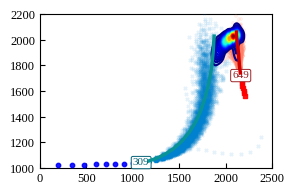

In [23]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(0,2500,1000,2200,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1742,
    vehicle_id="VEHICLE/309",
    ped="PEDESTRIAN/649",
    bg_path=BG_IMG_PATH,
    contour_levels=45)
    # save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Veh_309_ped_649.png')

In [24]:
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1742,
    "VEHICLE/309", "PEDESTRIAN/649"
)

In [25]:
spread

1.7906708014948418

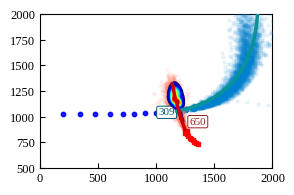

In [26]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(0,2000,500,2000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1742,
    vehicle_id="VEHICLE/309",
    ped="PEDESTRIAN/650",
    bg_path=BG_IMG_PATH,
    contour_levels=25,)
    # save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Veh_309_ped_650.png')

In [27]:
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1742,
    "VEHICLE/309", "PEDESTRIAN/650"
)

In [28]:
spread

1.2379575443204776

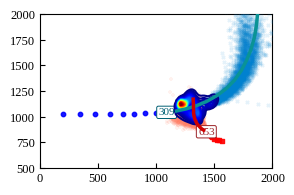

In [29]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(0,2000,500,2000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1742,
    vehicle_id="VEHICLE/309",
    ped="PEDESTRIAN/653",
    bg_path=BG_IMG_PATH,
    contour_levels=25)
    # save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Veh_300_ped_653.png')

In [30]:
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1742,
    "VEHICLE/309", "PEDESTRIAN/653"
)
spread

2.011343086087517

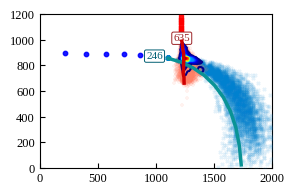

0.00015269474534906902 1.230771737560923


In [31]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(0,2000,0,1200,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1353,
    vehicle_id="VEHICLE/246",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25)
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1353,
    "VEHICLE/246", "PEDESTRIAN/635"
)


risk = two_conflict_risk(
    1353,
    "VEHICLE/246", "PEDESTRIAN/635"
)
print(risk,spread)
    # save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Veh_309_ped_649.png')

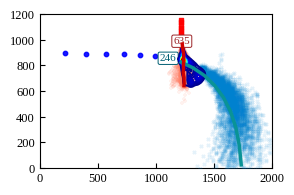

5.008465239508819e-05 1.8850333716080998


In [32]:
picture_with_field_single_peds_grid_style(0,2000,0,1200,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1354,
    vehicle_id="VEHICLE/246",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25)
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1354,
    "VEHICLE/246", "PEDESTRIAN/635"
)


risk = two_conflict_risk(
    1354,
    "VEHICLE/246", "PEDESTRIAN/635"
)
print(risk,spread)

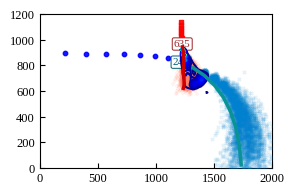

2.1224596039592925e-06 2.679127312679464


In [33]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(0,2000,0,1200,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1355,
    vehicle_id="VEHICLE/246",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25)
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1355,
    "VEHICLE/246", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1355,
    "VEHICLE/246", "PEDESTRIAN/635"
)
print(risk,spread)

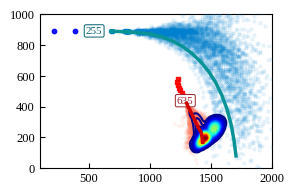

0.0033222103884719134 1.5697513959237959


In [34]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1381,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1381.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1381,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1381,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

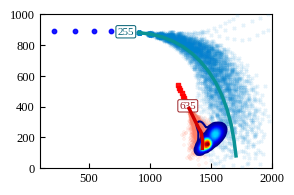

0.00728570416445129 1.4332464334893285


In [35]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1383,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1383.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1383,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1383,
    "VEHICLE/255", "PEDESTRIAN/635")
print(risk,spread)

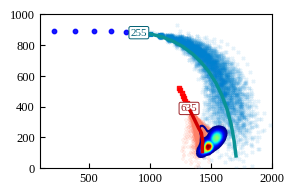

0.005986903702902446 1.3472638776330481


In [36]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1384,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1384.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1384,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1384,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

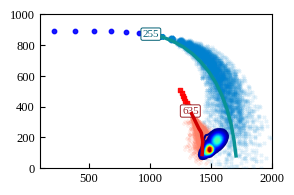

0.005935703795291958 1.3209605098895636


In [37]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1385,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1385.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1385,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1385,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

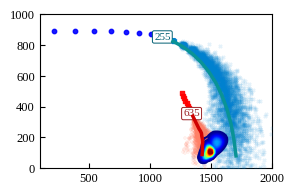

0.03427939900975252 1.2404776687866417


In [38]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1386,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1386.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1386,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1386,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

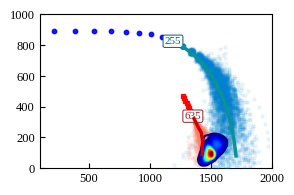

0.07717376935815834 1.2020631756510616


In [39]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1387,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1387.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1387,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1387,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

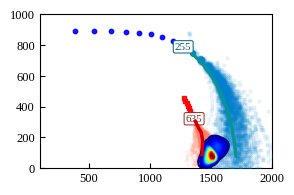

0.04846869174382484 1.189107055423411


In [40]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1388,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1388.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1388,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1388,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

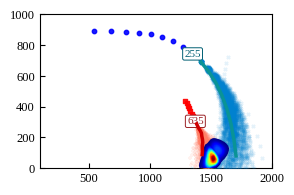

0.08505296876785162 1.1191729999991766


In [41]:
# ===== 正确调用：单个行人用 ped=... =====
picture_with_field_single_peds_grid_style(100,2000,0,1000,
    tra_data=tra_data,
    gaussian_parameter=gaussian_parameter,
    time_step=1389,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    bg_path=BG_IMG_PATH,
    contour_levels=25,save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VP_1389.svg')
spread, max_val, mean_val, median_val = risk_field_stats(
    gaussian_parameter,
    1389,
    "VEHICLE/255", "PEDESTRIAN/635"
)
risk = two_conflict_risk(
    1389,
    "VEHICLE/255", "PEDESTRIAN/635"
)
print(risk,spread)

In [42]:
x, y = np.mgrid[-10:3840/48.3:0.2, -10:2160/46.6:0.2]   # world-grid
X = _tx(x)  # pixel-grid
Y = _ty(y)  # pixel-grid

In [43]:
def picture_field_2d_single_pair(
    x1, x2, y1, y2,
    gaussian_parameter,
    time_step, vehicle_id, ped,
    contour_levels=30,
    upper_pct=99,
    save_name=None,
    z_scale=1.0,
    stride=1,            # 2D下采样步长：1=不下采样；3/5可明显加速
    draw_contour=True    # 是否叠加等高线线条
):
    """
    只画场强的 2D 图（contourf + contour），不画轨迹、不画背景。

    依赖外部已存在：
      - x, y : np.mgrid 生成的 world 网格（shape = (H,W)）
      - X, Y : 对应像素网格（shape = (H,W)），例如 X=_tx(x), Y=_ty(y)
      - two_agent_conflict_p(...)
      - replace_outliers_custom(mat, upper_pct=...)
    """

    # ---------- 1) 计算单对(veh,ped)场强 ----------
    veh_name = [vehicle_id, ped]
    mats = [two_agent_conflict_p(gaussian_parameter, time_step, idx, veh_name) for idx in range(16)]
    field_pair = np.sum(mats, axis=0)

    if field_pair.shape != x.shape:
        raise ValueError(
            f"two_agent_conflict_p 输出 shape={field_pair.shape} 与网格 x.shape={x.shape} 不一致。\n"
            f"你需要：\n"
            f"  (1) 让 two_agent_conflict_p 内部用同一套 x,y 网格计算；或\n"
            f"  (2) 把 np.mgrid 的范围/步长改到与 field_pair.shape 匹配。"
        )

    # 去极值（你现在想保留原值就直接用 field_pair）
    field_clean = field_pair  # 或：replace_outliers_custom(field_pair, upper_pct=upper_pct)

    # ---------- 2) 按像素范围裁剪 ----------
    mask = (X >= x1) & (X <= x2) & (Y >= y1) & (Y <= y2)
    if not np.any(mask):
        raise ValueError("裁剪范围内没有网格点，请检查 x1,x2,y1,y2 是否合理。")

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    Xc = X[r0:r1, c0:c1]
    Yc = Y[r0:r1, c0:c1]
    Zc = field_clean[r0:r1, c0:c1] #* float(z_scale)

    # ---------- 3) 颜色范围 ----------
    vmin, vmax = np.nanmin(Zc), np.nanmax(Zc)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ---------- 4) 2D 绘图 ----------
    fig, ax = plt.subplots(figsize=(4,3))

    # 下采样（加速）
    Xs = Xc[::stride, ::stride]
    Ys = Yc[::stride, ::stride]
    Zs = Zc[::stride, ::stride]

    # 2D 填色等值线
    cf = ax.contour(
        Xs, Ys, Zs,
        levels=contour_levels,
        cmap="jet",
        norm=norm,
        alpha=1.0
    )

    # 可选：叠加线条等值线
    if draw_contour:
        cs = ax.contour(
            Xs, Ys, Zs,
            levels=max(8, contour_levels // 2),
            cmap="jet",
            norm=norm,
            linewidths=0.8,
            alpha=1
        )
        # ax.clabel(cs, inline=True, fmt="%.2e", fontsize=8)  # 需要标注数值再打开

    # 坐标与标题
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_aspect("equal", adjustable="box")


    # colorbar
    sm = ScalarMappable(norm=norm, cmap="jet")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label(r'$\mathcal{R}(\mathbf{x})$')

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight", pad_inches=0.05)

    plt.show()
    return fig, ax

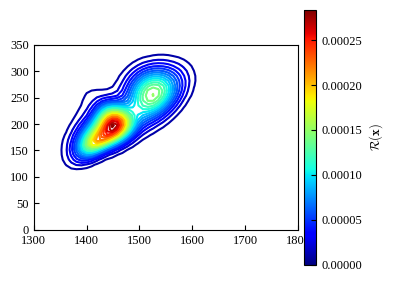

(<Figure size 400x300 with 2 Axes>, <AxesSubplot:>)

In [44]:
picture_field_2d_single_pair(
    x1=1300, x2=1800, y1=0, y2=350,
    gaussian_parameter=gaussian_parameter,
    time_step=1381,
    vehicle_id="VEHICLE/255",
    ped="PEDESTRIAN/635",
    stride=1,          # 数据大就调大些，比如 4~8
    z_scale=6.0,       # 如果太小看不清，可试 1e6 / 1e8
    save_name=None
)

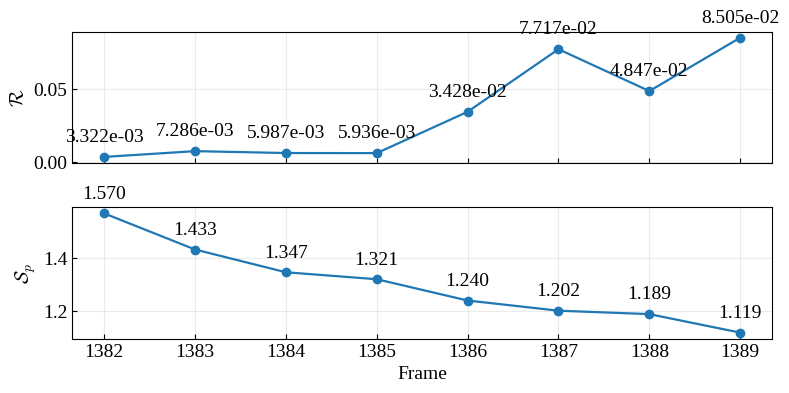

In [50]:
# ===== 你的数据（8 个帧：1382~1389）=====
frames = np.arange(1382, 1390)

R = np.array([
    0.0033222103884719134,
    0.00728570416445129,
    0.005986903702902446,
    0.005935703795291958,
    0.03427939900975252,
    0.07717376935815834,
    0.04846869174382484,
    0.08505296876785162
], dtype=float)

Sp = np.array([
    1.5697513959237959,
    1.4332464334893285,
    1.3472638776330481,
    1.3209605098895636,
    1.2404776687866417,
    1.2020631756510616,
    1.189107055423411,
    1.1191729999991766
], dtype=float)

# ===== 画图：上下两幅 =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,4), sharex=True)

# --- 上图：R ---
ax1.plot(frames, R, marker='o', linewidth=1.6)
ax1.set_ylabel(r'$\mathcal{R}$', fontsize=14)
ax1.grid(alpha=0.25)

# 给 R 每个点标数值
dy1 = 0.03 * (np.nanmax(R) - np.nanmin(R) + 1e-30)
for f, y in zip(frames, R):
    ax1.annotate(f"{y:.3e}", (f, y),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", va="bottom", fontsize=14)

# --- 下图：Sp ---
ax2.plot(frames, Sp, marker='o', linewidth=1.6)
ax2.set_xlabel("Frame", fontsize=14)
ax2.set_ylabel(r'$\mathcal{S}_{p}$', fontsize=14)
ax2.grid(alpha=0.25)

# 给 Sp 每个点标数值
dy2 = 0.03 * (np.nanmax(Sp) - np.nanmin(Sp) + 1e-30)
for f, y in zip(frames, Sp):
    ax2.annotate(f"{y:.3f}", (f, y),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", va="bottom", fontsize=14)

# x 轴刻度就是每个帧
ax2.set_xticks(frames)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/line.svg', dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

In [52]:
mus_arr_ped_649, sig_arr_ped_649, logpi_arr_ped_649, corr_arr_ped_649,_=gaussian_parameter(1742, 'PEDESTRIAN/649')
mus_arr_veh_309, sig_arr_veh_309, logpi_arr_veh_309, corr_arr_veh_309,_=gaussian_parameter(1742, 'VEHICLE/309')

In [53]:
mus_arr_veh_309.shape

(16, 25, 2)

In [54]:
def gmm_overlap_score(mus1, sigmas1, log_pis1, corrs1,
                      mus2, sigmas2, log_pis2, corrs2):
    """
    计算双 GMM 交互核
        S = Σ_m Σ_n  π_m^1 π_n^2  exp( -½ D_mn² )
    Parameters
    ----------
    mus1, mus2         : (K, 2)      - μ = (μx, μy)
    sigmas1, sigmas2   : (K, 2)      - σ = (σx, σy)
    corrs1, corrs2     : (K,)        - ρ
    log_pis1, log_pis2 : (K,)        - log π
    Returns
    -------
    S : float
    """
    # 转成 ndarray，确保为 float64 精度
    mus1     = np.asarray(mus1,     dtype=np.float64)
    mus2     = np.asarray(mus2,     dtype=np.float64)
    sigmas1  = np.asarray(sigmas1,  dtype=np.float64)
    sigmas2  = np.asarray(sigmas2,  dtype=np.float64)
    corrs1   = np.asarray(corrs1,   dtype=np.float64)
    corrs2   = np.asarray(corrs2,   dtype=np.float64)
    w1       = np.exp(np.asarray(log_pis1, dtype=np.float64))   # (25,)
    w2       = np.exp(np.asarray(log_pis2, dtype=np.float64))   # (25,)
    # ---------- (1) μ 差分 ----------
    delta = mus1[:, None, :] - mus2[None, :, :]     # shape (25, 25, 2)
    dx, dy = delta[..., 0], delta[..., 1]           # (25,25)
    # ---------- (2) Σ_i + Σ_j 的元素 ----------
    sx1, sy1 = sigmas1[:, 0], sigmas1[:, 1]         # (25,)
    sx2, sy2 = sigmas2[:, 0], sigmas2[:, 1]
    a = sx1[:, None]**2 + sx2[None, :]**2           # Σ₁₁ 元素 -> a  (25,25)
    c = sy1[:, None]**2 + sy2[None, :]**2           # Σ₂₂ 元素 -> c
    b = (corrs1[:, None] * sx1[:, None] * sy1[:, None] +
         corrs2[None, :] * sx2[None, :] * sy2[None, :])         # off-diag
    det = a * c - b**2                              # |Σ₁+Σ₂|  (25,25)
    # ---------- (3) Mahalanobis   dᵀ Σ⁻¹ d ----------
    # Σ⁻¹ = 1/det * [[ c, -b],[-b, a]]
    D2 = (c * dx**2 + a * dy**2 - 2 * b * dx * dy) / det   # (25,25)
    # ---------- (4) 权重外积 ----------
    W = w1[:, None] * w2[None, :]                   # (25,25)
    return np.sum(W * np.exp(-0.5 * D2) / (2*np.pi*np.sqrt(det)))

In [57]:
def two_conflict_risk(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]
    return risk_c

In [58]:
two_conflict_risk(1742,'VEHICLE/309','PEDESTRIAN/649')

[0.0,
 0.0,
 3.1155298303484816e-117,
 1.6776059176525518e-62,
 1.9179352340259125e-43,
 2.5631062875957887e-35,
 3.8705652725923244e-29,
 8.891912287488096e-24,
 7.650778222278534e-20,
 1.453907624273064e-16,
 6.635766053609564e-12,
 6.399860160469164e-09,
 7.47574174426556e-07,
 1.9747269291152676e-05,
 0.00011869031123790992,
 0.00020829152548957534]

In [59]:
import time

In [60]:
# =========================
def gmm_risk_closed_form(mus1, sigmas1, log_pis1, corrs1,
                         mus2, sigmas2, log_pis2, corrs2,
                         eps=1e-12, normalize_weights=True):
    mus1    = np.asarray(mus1,    dtype=np.float64)
    mus2    = np.asarray(mus2,    dtype=np.float64)
    sigmas1 = np.asarray(sigmas1, dtype=np.float64)
    sigmas2 = np.asarray(sigmas2, dtype=np.float64)
    corrs1  = np.asarray(corrs1,  dtype=np.float64)
    corrs2  = np.asarray(corrs2,  dtype=np.float64)

    w1 = np.exp(np.asarray(log_pis1, dtype=np.float64))
    w2 = np.exp(np.asarray(log_pis2, dtype=np.float64))
    if normalize_weights:
        s1 = w1.sum()
        s2 = w2.sum()
        if s1 > 0: w1 = w1 / s1
        if s2 > 0: w2 = w2 / s2

    corrs1 = np.clip(corrs1, -1.0 + 1e-6, 1.0 - 1e-6)
    corrs2 = np.clip(corrs2, -1.0 + 1e-6, 1.0 - 1e-6)

    delta = mus1[:, None, :] - mus2[None, :, :]
    dx, dy = delta[..., 0], delta[..., 1]

    sx1, sy1 = sigmas1[:, 0], sigmas1[:, 1]
    sx2, sy2 = sigmas2[:, 0], sigmas2[:, 1]

    a = sx1[:, None]**2 + sx2[None, :]**2
    c = sy1[:, None]**2 + sy2[None, :]**2
    b = (corrs1[:, None] * sx1[:, None] * sy1[:, None] +
         corrs2[None, :] * sx2[None, :] * sy2[None, :])

    det = a * c - b**2
    det = np.maximum(det, eps)

    K = (c * dx**2 + a * dy**2 - 2.0 * b * dx * dy) / det

    W = w1[:, None] * w2[None, :]
    norm_factor = 2.0 * np.pi * np.sqrt(det)

    R = np.sum(W * np.exp(-0.5 * K) / norm_factor)
    return float(R)

# =========================
# 2) 旧版随机工具（RandomState）
# =========================
def _get_rs(seed=None):
    return np.random.RandomState(seed) if seed is not None else np.random

# =========================
# 3) 采样：X ~ p1
# =========================
def sample_from_gmm(mus, sigmas, log_pis, corrs, N, rs=None, normalize_weights=True):
    if rs is None:
        rs = _get_rs(None)

    mus = np.asarray(mus, float)
    sigmas = np.asarray(sigmas, float)
    corrs = np.asarray(corrs, float)
    w = np.exp(np.asarray(log_pis, float))

    if normalize_weights:
        s = w.sum()
        if s > 0: w = w / s

    K = mus.shape[0]

    # 用 CDF + searchsorted 兼容老版本
    u = rs.rand(N)
    cdf = np.cumsum(w)
    cdf[-1] = 1.0
    comp = np.searchsorted(cdf, u)

    samples = np.zeros((N, 2), dtype=np.float64)
    for k in range(K):
        idx = np.where(comp == k)[0]
        if idx.size == 0:
            continue
        mu = mus[k]
        sx, sy = sigmas[k]
        rho = float(np.clip(corrs[k], -1.0 + 1e-6, 1.0 - 1e-6))
        cov = np.array([[sx*sx, rho*sx*sy],
                        [rho*sx*sy, sy*sy]], dtype=np.float64)
        samples[idx] = rs.multivariate_normal(mean=mu, cov=cov, size=idx.size)
    return samples

# =========================
# 4) 计算 GMM pdf：p2(x)
# =========================
def gmm_pdf(points, mus, sigmas, log_pis, corrs, eps=1e-12, normalize_weights=True):
    X = np.asarray(points, float)
    mus = np.asarray(mus, float)
    sigmas = np.asarray(sigmas, float)
    corrs = np.asarray(corrs, float)
    w = np.exp(np.asarray(log_pis, float))

    if normalize_weights:
        s = w.sum()
        if s > 0: w = w / s

    d = X[None, :, :] - mus[:, None, :]
    dx = d[..., 0]
    dy = d[..., 1]

    sx = sigmas[:, 0][:, None]
    sy = sigmas[:, 1][:, None]
    rho = np.clip(corrs, -1.0 + 1e-6, 1.0 - 1e-6)[:, None]

    one_minus = np.maximum(1.0 - rho**2, eps)
    z = (dx/sx)**2 + (dy/sy)**2 - 2.0*rho*(dx/sx)*(dy/sy)
    z = z / one_minus

    coef = 1.0 / (2.0*np.pi*sx*sy*np.sqrt(one_minus))
    pdf_comp = coef * np.exp(-0.5*z)
    pdf = (w[:, None] * pdf_comp).sum(axis=0)
    return pdf

# =========================
# 5) MC 单步估计：Rk = E_{X~p1}[p2(X)]
# =========================
def mc_overlap_estimate(mus1, sigmas1, log_pis1, corrs1,
                        mus2, sigmas2, log_pis2, corrs2,
                        N, rs=None):
    X = sample_from_gmm(mus1, sigmas1, log_pis1, corrs1, N, rs=rs, normalize_weights=True)
    p2 = gmm_pdf(X, mus2, sigmas2, log_pis2, corrs2, normalize_weights=True)
    return float(np.mean(p2))

# =========================
# 6) 从 gaussian_parameter 取某个 step 的 GMM 参数
# =========================
def get_gmm_at_step(gaussian_parameter, time_step, agent, step):
    mus, sigmas, log_probs, corrs, *_ = gaussian_parameter(time_step, agent)
    return mus[step], sigmas[step], log_probs[step], corrs[step]

# =========================
# 7) 计算 16 个时间步累计：真值 & MC估计
# =========================
def exact_sum_over_steps(gaussian_parameter, time_step, veh, ped, steps=16):
    total = 0.0
    for k in range(steps):
        mus1, sig1, logp1, rho1 = get_gmm_at_step(gaussian_parameter, time_step, veh, k)
        mus2, sig2, logp2, rho2 = get_gmm_at_step(gaussian_parameter, time_step, ped, k)
        total += gmm_risk_closed_form(mus1, sig1, logp1, rho1, mus2, sig2, logp2, rho2)
    return total

def mc_sum_over_steps(gaussian_parameter, time_step, veh, ped, steps=16, N=5000, seed=0):
    total = 0.0
    for k in range(steps):
        mus1, sig1, logp1, rho1 = get_gmm_at_step(gaussian_parameter, time_step, veh, k)
        mus2, sig2, logp2, rho2 = get_gmm_at_step(gaussian_parameter, time_step, ped, k)

        rs = _get_rs(seed + 1000*k)  # 每个 step 不同随机流，避免相关
        total += mc_overlap_estimate(mus1, sig1, logp1, rho1, mus2, sig2, logp2, rho2, N=N, rs=rs)
    return total

0.007412472972646356
0.007039042189717293
0.006730285938829184
0.006688551977276802


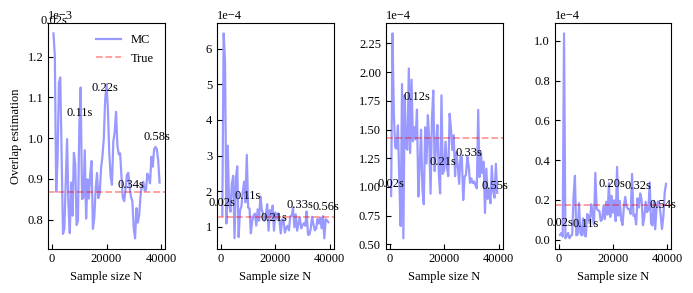

In [61]:
def run_mc_time_value_curve_grid_1x4(
    gaussian_parameter,
    time_step=1742,
    veh="VEHICLE/309",
    peds=("PEDESTRIAN/649","PEDESTRIAN/650","PEDESTRIAN/651","PEDESTRIAN/653"),
    steps=16,
    Ns=None,
    seed=0,
    annotate_every=10
):
    if Ns is None:
        Ns = [500*i for i in range(1, 50)]
    Ns = np.asarray(Ns, dtype=int)

    fig, axes = plt.subplots(1, 4, figsize=(7,3), sharex=True, sharey=False)
    if len(peds) != 4:
        raise ValueError("peds 必须是 4 个行人ID，才能对应 1×4 子图。")

    for ax, ped in zip(axes, peds):
        # 真值累计
        t_0_true = time.perf_counter()
        true_sum = exact_sum_over_steps(gaussian_parameter, time_step, veh, ped, steps=steps)
        t_1_true = time.perf_counter()
        
        print(t_1_true  - t_0_true )

        times = []
        estimates = []

        for N in Ns:
            t0 = time.perf_counter()
            est_sum = mc_sum_over_steps(
                gaussian_parameter, time_step, veh, ped,
                steps=steps, N=int(N), seed=seed
            )
            t1 = time.perf_counter()
            times.append(t1 - t0)
            estimates.append(est_sum)

        times = np.asarray(times, float)
        estimates = np.asarray(estimates, float)

        # 曲线 + 真值横线
        ax.plot(Ns, estimates, linewidth=1.6, c='blue',alpha=0.4,label="MC")
        ax.axhline(true_sum, linestyle='--', c='red',linewidth=1.3, alpha=0.4,label="True")

        ax.set_xlabel("Sample size N")
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # 推荐

        # 每隔 annotate_every 个点标一次耗时
        y_min = np.nanmin(np.r_[estimates, true_sum])
        y_max = np.nanmax(np.r_[estimates, true_sum])
        dy = 0.03 * (y_max - y_min + 1e-30)

        for i, (x, y, tsec) in enumerate(zip(Ns, estimates, times)):
            if i % annotate_every != 0:
                continue
            ax.text(x, y + dy, f"{tsec:.2f}s", ha="center", va="bottom", alpha=1)

        # 图例只放第一个子图（更干净）
        if ax is axes[0]:
            ax.legend(frameon=False,loc='upper right')
    axes[0].set_ylabel("Overlap estimation")
    plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/time_consum.svg', dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.tight_layout()
    plt.show()


# ===== 直接运行 =====
run_mc_time_value_curve_grid_1x4(
    gaussian_parameter=gaussian_parameter,
    time_step=1742,
    veh="VEHICLE/309",
    peds=("PEDESTRIAN/649","PEDESTRIAN/650","PEDESTRIAN/651","PEDESTRIAN/653"),
    steps=16,
    Ns=[500*i for i in range(1,80)],
    seed=0,
    annotate_every=19)

In [64]:
def picture(agent_A, agent_B, time_duration, label_A, label_B, label_A_1, label_B_1, save_name):
    fig, axes = plt.subplots(2, 4, figsize=(12, 4), gridspec_kw={'hspace': 0.34})
    axes = axes.ravel()  # ★ 关键：拉平成一维，axes[i] 才是一个 Axes

    # 可选：保护，避免时间步超过子图数量
    if len(time_duration) > len(axes):
        raise ValueError(f"time_duration 长度 {len(time_duration)} 超过子图数量 {len(axes)}")

    legend_handles, legend_labels = [], []
    for i, timestep in enumerate(time_duration):
        ax = axes[i]
        # 你的数据获取
        tru_A, his_A, pre_A = tra_data(timestep, agent_B)
        tru_B, his_B, pre_B = tra_data(timestep, agent_A)
        # 保护：如果某一侧没有预测，跳过避免 shape 错误
        if pre_A is None or pre_B is None:
            ax.set_title(f"Frame {timestep} (无数据)")
            ax.axis('off')
            continue
        # 取重叠的时间长度
        T = min(pre_A.shape[1], pre_B.shape[1])
        reds  = plt.cm.Reds (np.linspace(1.0, 0.3, T))
        blues = plt.cm.Blues(np.linspace(1.0, 0.3, T))

        # 画未来散点（第 j 个时间层）
        for j in range(T):
            ax.scatter(pre_A[..., j, 0].ravel()* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_A[..., j, 1].ravel()*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), s=3, alpha=0.3, c=[reds[j]])
            ax.scatter(pre_B[..., j, 0].ravel()* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_B[..., j, 1].ravel()*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), s=3, alpha=0.3, c=[blues[j]])

        # 历史轨迹与当前点（只在第一个子图加图例句柄）
        if i == 0:
            hA, = ax.plot(his_A[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_A[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#ff8066', alpha=1, linestyle='--', label=label_A)
            hB, = ax.plot(his_B[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_B[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#0081cf', alpha=1, linestyle='--', label=label_B)
            pA  = ax.scatter(his_A[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_A[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#ff8066', alpha=0.7, label=label_A_1)
            pB  = ax.scatter(his_B[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_B[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#0081cf', alpha=0.7, marker='*', label=label_B_1)
            legend_handles.extend([hA, hB, pA, pB])
            legend_labels.extend([label_A, label_B, label_A_1, label_B_1])
        else:
            ax.plot(his_A[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_A[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#ff8066', alpha=1, linestyle='--')
            ax.plot(his_B[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_B[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#0081cf', alpha=1, linestyle='--')
            ax.scatter(his_A[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_A[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#ff8066', alpha=0.7)
            ax.scatter(his_B[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_B[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), color='#0081cf', alpha=0.7, marker='*')

        ax.set_xlabel(f'({chr(97 + i)}) Frame {timestep}')
        # ax.set_xlim(0, 3840)
        # ax.set_ylim( 0,2160)   # 坐标原点在左上角
        # ax.xaxis.set_major_locator(ticker.MultipleLocator(218))
        # ax.yaxis.set_major_locator(ticker.MultipleLocator(232))

    # 统一图例（如果需要）
    if legend_handles:
        fig.legend(handles=legend_handles,
                   labels=legend_labels,
                   loc='lower center',
                   ncol=4,
                   bbox_to_anchor=(0.5, -0.08))

    # 保存或显示
    # plt.savefig(save_name, dpi=300, format="png", bbox_inches='tight', pad_inches=0)
    plt.show()

KeyError: 'PEDESTRIAN/579'

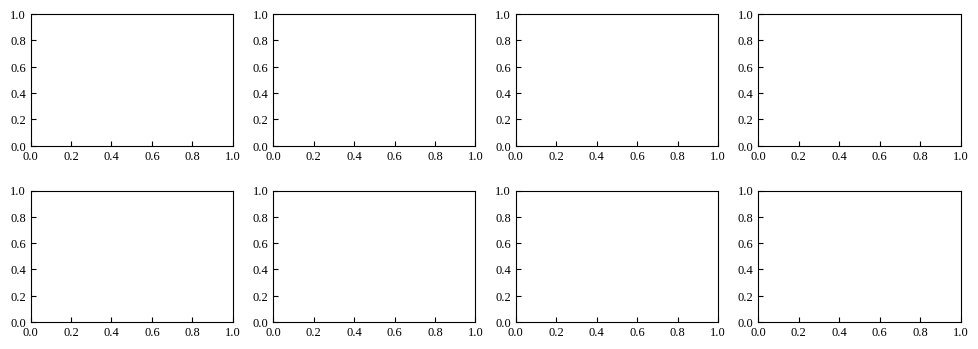

In [65]:
picture('VEHICLE/103','PEDESTRIAN/579',range(1320,1320+24,3),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

KeyError: '2017'

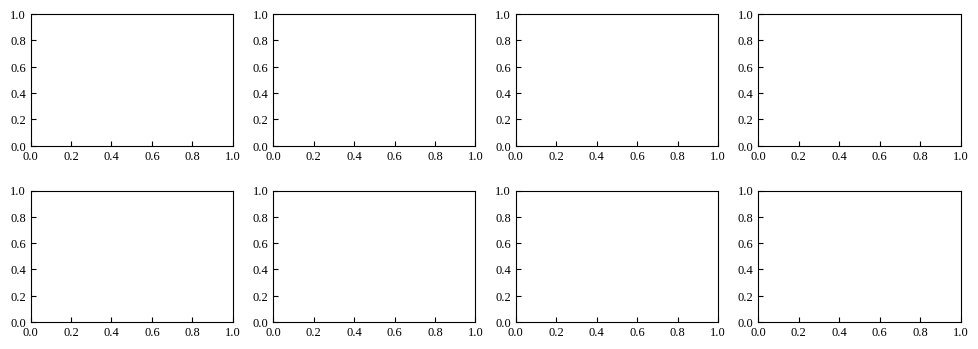

In [66]:
picture('VEHICLE/166','PEDESTRIAN/589',range(2017,2017+24,3),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

KeyError: '2082'

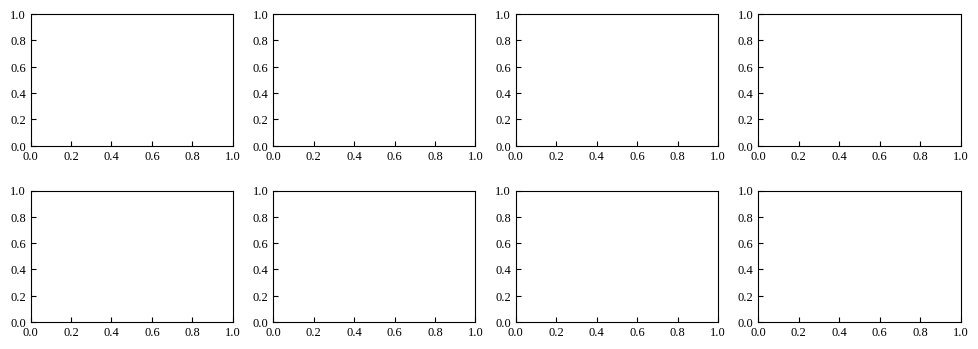

In [67]:
picture('VEHICLE/176','PEDESTRIAN/589',range(2082,2082+24,3),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

KeyError: '2151'

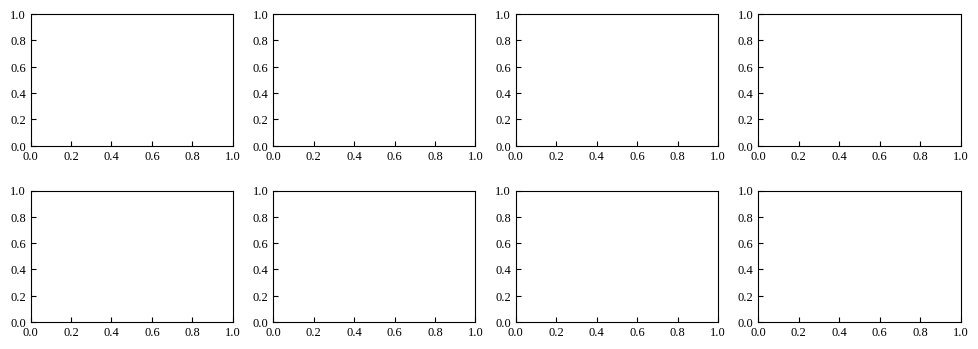

In [68]:
picture('VEHICLE/182','PEDESTRIAN/590',range(2151,2151+24,3),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

In [69]:
def decimal_formatter(x, pos):
    return f'{x:.1e}'  # 科学计数法，保留1位小数

def cr(time_step, pre_time_step, name_agent):
    """
    对每个 agent：
      - 取 pre_time_step 上 log_probs 最大的那个高斯分量（top-1）
      - 仅用该分量计算 bivariate_gaussian 的 Z
    返回：
      F: shape = (num_grid_points, n_agents)
    依赖：
      - gaussian_parameter(time_step, vid) -> (mus, sigmas, log_probs, corrs)
      - bivariate_gaussian(x, y, m, sx, sy, rho)
      - 全局网格 x, y
    """
    f_n = []
    for vid in name_agent:
        mus, sigmas, log_probs, corrs = gaussian_parameter(time_step, vid)  # mus: (T, K, 2)

        lp_t = np.asarray(log_probs[pre_time_step], dtype=np.float64)       # (K,)
        k = int(np.argmax(lp_t))

        m = np.asarray(mus[pre_time_step][k], dtype=np.float64)             # (2,)
        sx, sy = np.asarray(sigmas[pre_time_step][k], dtype=np.float64)     # (2,) -> sx, sy
        rho = float(corrs[pre_time_step][k])

        z = bivariate_gaussian(x, y, m, sx, sy, rho)                        # x.shape
        f_n.append(z.reshape(-1))

    F = np.stack(f_n, axis=1)  # (num_grid_points, n_agents)
    return F

def two_agent_conflict_p(time_step, pre_time_step, name_agent):
    """
    场强定义：两两组合的 (z_i * z_j)^{0.5}
    - 若 len(name_agent) == 2，则返回 sqrt(z1 * z2)
    - 若 >2，则对所有 i<j 做和：sum_{i<j} sqrt(z_i * z_j)
    """
    F = cr(time_step, pre_time_step, name_agent)              # (P, N)
    P, N = F.shape
    if N == 1:
        # 只有一个 agent，无法构造乘积，返回全零
        result = np.zeros(P, dtype=np.float64)
    elif N == 2:
        z1, z2 = F[:, 0], F[:, 1]
        result = np.sqrt(z1 * z2)
    else:
        acc = np.zeros(P, dtype=np.float64)
        for i, j in combinations(range(N), 2):
            acc += np.sqrt(F[:, i] * F[:, j])
        result = acc
    return result.reshape(x.shape[0], x.shape[1])

# 网格
x, y = np.mgrid[0:3840/48:0.5, 0:2160/48:0.5]

def two_agent(time_range, agent_name):
    fig, axes = plt.subplots(2, 4, figsize=(12, 4), gridspec_kw={'hspace': 0.4})
    axes = axes.flatten()

    contour_for_cbar = None

    for i, timestep in enumerate(time_range):
        ax = axes[i]
        # 累积未来步，带衰减权重
        result_matrices = [two_agent_conflict_p(timestep, idx, agent_name) for idx in range(12)]        
        
        risk_field = sum(result_matrices[j] * (1 ** j) for j in range(len(result_matrices)))

        contour = ax.contour(x * 56.5, y * 56.5, risk_field, levels=250, cmap='jet')
        contour_for_cbar = contour

        # ax.set_xlim(1500, 3200)
        # ax.set_ylim(2160, 0)
        ax.set_xlabel(f'({chr(97 + i)}) Frame {timestep} ')
        # ax.xaxis.set_major_locator(ticker.MultipleLocator(218))
        # ax.yaxis.set_major_locator(ticker.MultipleLocator(232))
        ax.grid()

    cbar = fig.colorbar(contour_for_cbar, ax=axes, shrink=0.95, aspect=25, pad=0.02)
    cbar.set_label('R')
    cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(decimal_formatter))

    plt.tight_layout()
    plt.show()

In [70]:
'VEHICLE/182','PEDESTRIAN/590',range(2151,2151+24,3)

('VEHICLE/182', 'PEDESTRIAN/590', range(2151, 2175, 3))

ValueError: time_step=2151 下没有找到 VEHICLE/182

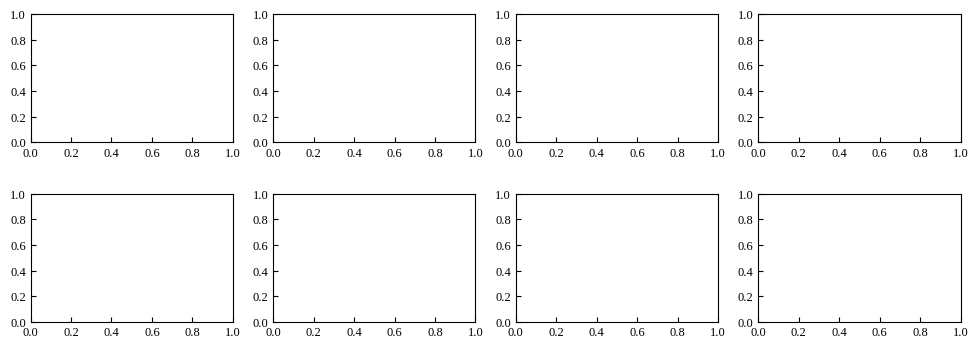

In [71]:
two_agent(range(2151,2151+24,3), ['VEHICLE/182','PEDESTRIAN/590'])

In [72]:
def compute_collision_probability(lambda_list, T=2.4):
    """
    lambda_list: 长度为12的列表或numpy数组，对应Gauss-Legendre 12点的 λ(t_i)
    T: 积分上限（默认2.4秒）
    返回：1 - exp(-∫ λ(t) dt)
    """
    lambda_list = np.asarray(lambda_list, dtype=float)
    # 1) 获取12点Gauss-Legendre权重（w_i）和节点（x_i）
    # 注意此处 t_i 已经不需要使用，只需要 w_i
    x, w = leggauss(12)
    # 2) 积分系数 J = T/2
    J = T / 2.0
    # 3) Gauss–Legendre 求积
    integral = J * np.sum(w * lambda_list)
    # 4) 计算 1 - exp(-integral)
    prob = 1 - np.exp(-integral)
    return float(prob)

In [73]:
# —— 计算二维均匀网格上的积分：sum(Z) * dx * dy ——
def _integrate2d_uniform(Z, x, y):
    """
    Z: 2D array, same shape as x,y
    x,y: meshgrids (e.g., from np.mgrid), assumed uniform spacing
    """
    Z = np.asarray(Z, dtype=float)
    Z = np.nan_to_num(Z)  # 清理 NaN/Inf，全部当 0 处理

    # 从网格里推断均匀步长（取中位数更稳）
    # x 方向：取一列，y 方向：取一行
    xi = np.unique(x[:, 0])
    yi = np.unique(y[0, :])

    if len(xi) > 1:
        dx = float(np.median(np.diff(xi)))
    else:
        dx = 1.0
    if len(yi) > 1:
        dy = float(np.median(np.diff(yi)))
    else:
        dy = 1.0

    return Z.sum() * dx * dy

# —— 计算给定 (time_step, pre_time_step) 的 BC 值 ——
def bc_at_prestep(time_step, pre_time_step, name_agent):
    """
    time_step: 当前帧
    pre_time_step: 预测的第 k 个未来步（或你想计算的那个时间切片）
    name_agent: ['VEHICLE/xxx','PEDESTRIAN/yyy'] 两个智能体的名字
    返回：该时间切片的数值 BC
    """
    # 得到 sqrt(p q) 的网格场（two_agent_conflict_p 已经返回 sqrt(z1*z2)）
    field = two_agent_conflict_p(time_step, pre_time_step, name_agent)  # shape == x.shape
    bc_val = _integrate2d_uniform(field, x, y)
    # 可选：BC ∈ [0,1]，如果你的网格有限域截断导致总概率<1，可以不强行裁剪
    return float(max(bc_val, 0.0))

# —— 计算“一个 time_step 下”所有 pre_time_step=0..(horizon-1) 的 BC 曲线 ——
def bc_curve_for_time(time_step, name_agent, horizon=12):
    """
    返回：长度为 horizon 的数组，元素是每个 pre_time_step 的 BC
    """
    vals = []
    for k in range(horizon):
        vals.append(bc_at_prestep(time_step, k, name_agent))
    return np.array(vals, dtype=float)

# —— 计算“一段时间范围内，每个 time_step 的 BC（对某个固定 pre_time_step 或全曲线）” ——
def bc_over_timerange(time_range, name_agent, horizon=12, return_curve=False):
    """
    time_range: 可迭代的时间帧序列（例如 range(2082, 2082+24, 3)）
    name_agent: 两个智能体名称
    horizon: 未来步数（与你模型里 T 对齐，默认 12）
    return_curve=False: 返回每个 time_step 的“聚合”BC（例如对 k 逐项求和）
                   True: 返回一个 dict，包含每个 time_step 的整条 BC 曲线
    """
    if return_curve:
        out = {}
        for t in time_range:
            out[int(t)] = bc_curve_for_time(t, name_agent, horizon=horizon)
        return out
    else:
        # 给一个“聚合指标”：把该 time_step 下的所有 pre_time_step 的 BC 累加
        vals = []
        for t in time_range:
            curve = bc_curve_for_time(t, name_agent, horizon=horizon)
            vals.append(curve.sum())
        return np.array(vals, dtype=float)

In [74]:
def two_agent_risk(time_range, agent_name):
    
    risk_range=[]
    
    for timestep in time_range:
        
   
        P=bc_curve_for_time(timestep, ['VEHICLE/182','PEDESTRIAN/590'], horizon=12)
  
    
        R=[i/(1-i) for i in P]
        
        print(P) 

        Risk=compute_collision_probability(R, T=2.4)
        
        risk_range.append(Risk)
    
    return risk_range

In [75]:
VPIR=two_agent_risk(range(2151,2151+24,3), ['VEHICLE/182','PEDESTRIAN/590'])

ValueError: time_step=2151 下没有找到 VEHICLE/182

In [76]:
plt.plot(range(2151,2151+24,1),VPIR)

NameError: name 'VPIR' is not defined

In [77]:
import numpy as np

def sample_traj(time_step, agent_id, num_samples=1000):
    """
    输入:
        time_step : int
        agent_id  : 'VEHICLE/17' 或 'PEDESTRIAN/177'
        num_samples : 采样轨迹条数 (默认1000)
    输出:
        samples : (num_samples, T, 2)
    """

    mus, sigmas, log_pis, corrs = gaussian_parameter(time_step, agent_id)
    # mus:    (T, K, 2)
    # sigmas: (T, K, 2)
    # log_pis:(T, K)
    # corrs:  (T, K)

    T, K, _ = mus.shape

    samples = np.zeros((num_samples, T, 2), dtype=np.float64)

    for t in range(T):
        # 该时间步的 mixture 权重
        pis = np.exp(log_pis[t])
        pis = pis / pis.sum()   # 归一化
        
        # 根据混合系数选择分量 k (size = num_samples)
        ks = np.random.choice(K, size=num_samples, p=pis)

        # 取出对应分量参数
        mu_t = mus[t][ks]                # (num_samples, 2)
        sx   = sigmas[t][ks, 0]          # (num_samples,)
        sy   = sigmas[t][ks, 1]
        rho  = corrs[t][ks]              # (num_samples,)

        # 构造 2×2 协方差矩阵
        cov = np.zeros((num_samples, 2, 2), dtype=np.float64)
        cov[:,0,0] = sx**2
        cov[:,1,1] = sy**2
        cov[:,0,1] = rho * sx * sy
        cov[:,1,0] = rho * sx * sy

        # 采样
        for i in range(num_samples):
            samples[i,t] = np.random.multivariate_normal(mu_t[i], cov[i])

    return samples

In [78]:
traj_samples = sample_traj(126, 'PEDESTRIAN/184', num_samples=1000)
print(traj_samples.shape)     # (1000, T, 2)

ValueError: time_step=126 下没有找到 PEDESTRIAN/184

In [79]:
car_traj_samples = sample_traj(126, 'VEHICLE/23', num_samples=1000)
print(traj_samples.shape)     # (1000, T, 2)

ValueError: time_step=126 下没有找到 VEHICLE/23

In [80]:
tru1,his1,pre1=tra_data(126,'PEDESTRIAN/184')
tru2,his2,pre2=tra_data(126,'VEHICLE/23')

KeyError: '126'

In [81]:
his1

NameError: name 'his1' is not defined

In [82]:
traj_samples_real = traj_samples * 56.5
car_traj_samples_real = car_traj_samples * 56.5

NameError: name 'traj_samples' is not defined

In [83]:
traj_samples_real.shape

NameError: name 'traj_samples_real' is not defined

In [84]:
def plot_samples_with_history(
        traj_samples_real, car_traj_samples_real,
        his1, his2,
        color_ped="#008e9b", color_car="#ffc75f"):
    """
    traj_samples_real      : (1000, T, 2) 行人采样轨迹
    car_traj_samples_real  : (1000, T, 2) 车辆采样轨迹
    his1, his2             : 历史轨迹 (H, 2)
    """

    T = traj_samples_real.shape[1]

    # 颜色渐变（从深到浅）
    ped_colors = np.array([plt.cm.get_cmap('Blues')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])
    car_colors = np.array([plt.cm.get_cmap('Reds')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])

    fig, ax = plt.subplots(figsize=(5,5))

    # —— 行人 1000×12 个点 —— #
    for t in range(T):
        ax.scatter(traj_samples_real[:, t, 0]-400, traj_samples_real[:, t, 1]+100,
                   s=24, alpha=0.35, color=ped_colors[t], edgecolors='none')

    # —— 车辆 1000×12 个点 —— #
    for t in range(T):
        ax.scatter(car_traj_samples_real[:, t, 0], car_traj_samples_real[:, t, 1],
                   s=24, alpha=0.35, color=car_colors[t], edgecolors='none')

    # —— 历史轨迹 —— #
    h1, = ax.plot(his1[:,0]-400, his1[:,1]+100, linestyle='--', linewidth=2.8, color=color_ped, label="Pedestrian History")
    h2, = ax.plot(his2[:,0], his2[:,1], linestyle='--', linewidth=2.8, color=color_car, label="Vehicle History")

    # —— 标注当前点 —— #
    p1 = ax.scatter(his1[-1,0]-400, his1[-1,1]+100, color=color_ped, s=80, marker='o', label="Pedestrian Now")
    p2 = ax.scatter(his2[-1,0], his2[-1,1], color=color_car, s=80, marker='*', label="Vehicle Now")

    ax.invert_yaxis()
    # ax.set_aspect('equal')
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_xlim([1200,3000])
    ax.set_ylim([500,1000])
    # —— 合并 legend —— #
    #ax.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/w.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
    plt.show()

In [85]:
plot_samples_with_history(
    traj_samples_real,        # (1000,12,2)
    car_traj_samples_real,    # (1000,12,2)
    his1, his2,
    color_ped="#08306b",
    color_car="#67000d")

NameError: name 'traj_samples_real' is not defined

In [86]:
def plot_samples_with_history(
        traj_samples_real, car_traj_samples_real,
        his1, his2,
        color_ped="#008e9b", color_car="#ffc75f"):
    """
    traj_samples_real      : (1000, T, 2) 行人采样轨迹
    car_traj_samples_real  : (1000, T, 2) 车辆采样轨迹
    his1, his2             : 历史轨迹 (H, 2)
    """

    T = traj_samples_real.shape[1]

    # 颜色渐变（从深到浅）
    ped_colors = np.array([plt.cm.get_cmap('Blues')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])
    car_colors = np.array([plt.cm.get_cmap('Reds')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])

    fig, ax = plt.subplots(figsize=(8,8))

#     # —— 行人 1000×12 个点 —— #
#     for t in range(T):
#         ax.scatter(traj_samples_real[:, t, 0]-400, traj_samples_real[:, t, 1]+100,
#                    s=24, alpha=0.35, color=ped_colors[t], edgecolors='none')

#     # —— 车辆 1000×12 个点 —— #
#     for t in range(T):
#         ax.scatter(car_traj_samples_real[:, t, 0], car_traj_samples_real[:, t, 1],
#                    s=24, alpha=0.35, color=car_colors[t], edgecolors='none')

    # —— 历史轨迹 —— #
    h1, = ax.plot(his1[:,0]-400, his1[:,1]+100, linestyle='--', linewidth=2.8, color=color_ped, label="Pedestrian History")
    h2, = ax.plot(his2[:,0], his2[:,1], linestyle='--', linewidth=2.8, color=color_car, label="Vehicle History")

    # —— 标注当前点 —— #
    p1 = ax.scatter(his1[-1,0]-400, his1[-1,1]+100, color=color_ped, s=80, marker='o', label="Pedestrian Now")
    p2 = ax.scatter(his2[-1,0], his2[-1,1], color=color_car, s=80, marker='*', label="Vehicle Now")

    ax.invert_yaxis()
    # ax.set_aspect('equal')
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_xlim([1200,3000])
    ax.set_ylim([500,1000])
    # —— 合并 legend —— #
    #ax.legend(loc='upper right', frameon=True)

    plt.tight_layout()
    plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/w1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
    plt.show()

In [87]:
plot_samples_with_history(
    traj_samples_real,        # (1000,12,2)
    car_traj_samples_real,    # (1000,12,2)
    his1, his2,
    color_ped="#08306b",
    color_car="#67000d"
)


NameError: name 'traj_samples_real' is not defined